## 1.0 Setup

1.1 Import Packages

In [22]:
import pandas as pd
import numpy as np
from PIL import Image, ImageOps
import os
from pathlib import Path
import matplotlib.pyplot as plt
import random

## 2.0 Scale Images

2.1 Apply transformation to one image

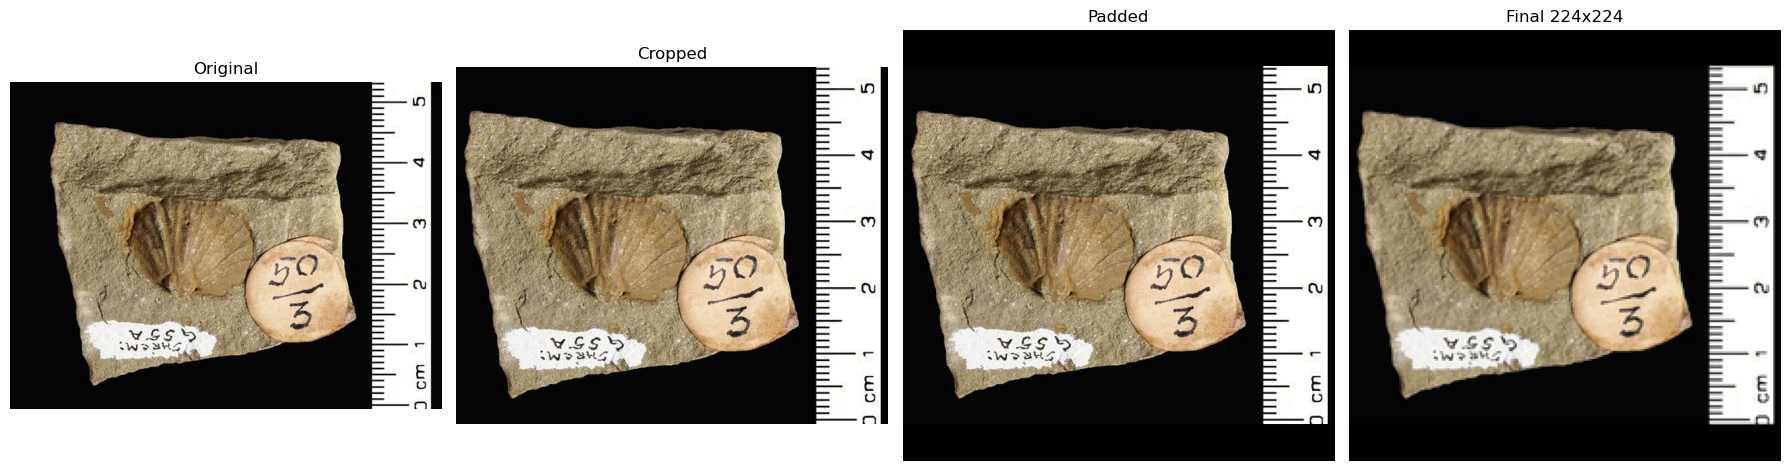

In [18]:
# import one image to test the cropping and resizing pipeline
img_path = "../Data/images/6650_Ordovician_Period_Brachiopod.jpg"

# Cropping function: find bounding box of non-background pixels and crop, with optional padding
def crop_to_fossil(img, threshold=30, padding=10):
    arr = np.array(img)
    mask = arr.max(axis=2) > threshold
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    h, w = arr.shape[:2]
    rmin = max(0, rmin - padding)
    rmax = min(h, rmax + padding)
    cmin = max(0, cmin - padding)
    cmax = min(w, cmax + padding)
    return img.crop((cmin, rmin, cmax, rmax))

# Padding function: pad the cropped image to a square shape, centered, with a specified fill color
def pad_to_square(img, fill=(0, 0, 0)):
    w, h = img.size
    size = max(w, h)  # square size based on longest side
    # Create a black square canvas and paste the image centered
    square = Image.new("RGB", (size, size), fill)
    offset = ((size - w) // 2, (size - h) // 2)
    square.paste(img, offset)
    return square

# Pipeline
img = Image.open(img_path).convert("RGB")
img_cropped = crop_to_fossil(img)
img_squared = pad_to_square(img_cropped)           # pad to square — no cropping
img_resized = img_squared.resize((224, 224), Image.LANCZOS)  # then resize

# Preview
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img);         axes[0].set_title("Original");    axes[0].axis("off")
axes[1].imshow(img_cropped); axes[1].set_title("Cropped");     axes[1].axis("off")
axes[2].imshow(img_squared); axes[2].set_title("Padded");      axes[2].axis("off")
axes[3].imshow(img_resized); axes[3].set_title("Final 224x224"); axes[3].axis("off")
plt.tight_layout()
plt.show()

2.2 Create New Directory For Cropped Image Files

In [19]:
# create new directory for processed images
processed_dir = "../Data/processed_images"
os.makedirs(processed_dir, exist_ok=True)

2.3 Process all images

In [20]:
# set up directories
input_dir = Path("../Data/images")
output_dir = Path("../Data/processed_images")
output_dir.mkdir(exist_ok=True)

# count number of images
image_paths = list(input_dir.glob("*.jpg")) + list(input_dir.glob("*.png"))
print(f"Found {len(image_paths)} images")

# Process each image: crop, pad, resize, and save
for img_path in image_paths:
    img = Image.open(img_path).convert("RGB")
    img_cropped = crop_to_fossil(img)
    img_squared = pad_to_square(img_cropped)
    img_resized = img_squared.resize((224, 224), Image.LANCZOS)
    img_resized.save(output_dir / img_path.name)

print("Done")

Found 2334 images
Done


## 3.0 Augment Dataset

3.1 Define Geometric Augmentation Function

In [39]:
# random geometric augmentations using the random library
def random_augment(img):    
    # Random horizontal flip
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    
    # Random rotation (-20 to +20 degrees)
    if random.random() > 0.5:
        angle = random.uniform(-20, 20)
        img = img.rotate(angle, fillcolor=(0, 0, 0))
    
    # Random zoom (crop center 80-100% then resize back)
    if random.random() > 0.5:
        w, h = img.size
        scale = random.uniform(0.80, 1.0)
        new_w, new_h = int(w * scale), int(h * scale)
        left = (w - new_w) // 2
        top = (h - new_h) // 2
        img = img.crop((left, top, left + new_w, top + new_h))
        img = img.resize((w, h), Image.LANCZOS)
    
    # Random brightness shift
    if random.random() > 0.5:
        arr = np.array(img, dtype=np.float32)
        shift = random.uniform(-30, 30)
        arr = np.clip(arr + shift, 0, 255).astype(np.uint8)
        img = Image.fromarray(arr)

    return img

3.2 Setup Augmentation

In [43]:
input_dir = Path("../Data/processed_images")
output_dir = Path("../Data/images_augmented")
output_dir.mkdir(exist_ok=True)

df = pd.read_csv("../Data/fossils_with_paths.csv")

# target number of images per class after augmentation
TARGET = 250

# copy originals first
for img_path in input_dir.glob("*.jpg"):
    img = Image.open(img_path)
    img.save(output_dir / img_path.name)

print("Originals copied")

Originals copied


In [44]:
# rebuild path names
df["local_path"] = df["local_path"].apply(
    lambda p: str(output_dir / Path(p).name)
)

# Verify paths
print(df["local_path"].head(5))
print("File exists check:", Path(df["local_path"].iloc[0]).exists())

0    ..\Data\images_augmented\6696_Silurian_Period_...
1    ..\Data\images_augmented\7620_Devonian_Period_...
2    ..\Data\images_augmented\6658_Silurian_Period_...
3    ..\Data\images_augmented\6673_Silurian_Period_...
4    ..\Data\images_augmented\6669_Silurian_Period_...
Name: local_path, dtype: object
File exists check: True


3.3 Augment Images

In [ ]:
# get current counts
class_counts = df["period"].value_counts()
new_rows = []  # collect new rows here, add to df at the end

# check if augmentation is needed for each class
for period, count in class_counts.items():
    if count >= TARGET:
        print(f"{period}: {count} images — skipping")
        continue
    
    # calculate how many more images are needed
    needed = TARGET - count
    print(f"{period}: {count} images — generating {needed} more")

    class_df = df[df["period"] == period]
    existing_paths = list(class_df["local_path"])

    # call augmentation function
    generated = 0
    while generated < needed:
        src_path = random.choice(existing_paths)
        img = Image.open(src_path).convert("RGB")
        img_aug = random_augment(img)

        save_name = f"{period.replace(' ', '_')}_{count + generated:04d}.jpg"
        save_path = output_dir / save_name
        img_aug.save(save_path)

        # Build new row
        src_row = class_df[class_df["local_path"] == src_path].iloc[0].copy()
        src_row["local_path"] = str(save_path)
        src_row["augmented"] = True   # flag so you can tell originals from augmented
        new_rows.append(src_row)

        generated += 1

# Add augmented rows to dataframe
if new_rows:
    aug_df = pd.DataFrame(new_rows)
    df["augmented"] = False  # mark originals
    df = pd.concat([df, aug_df], ignore_index=True)

# Save dataframe
df.to_csv("fossils_augmented.csv", index=False)
print(f"\nFinal dataset size: {len(df)} images")
print(df["period"].value_counts())

Silurian Period: 1024 images — skipping
Ordovician Period: 337 images — skipping
Carboniferous Period: 233 images — generating 17 more
Devonian Period: 223 images — generating 27 more
Cenozoic Era: 176 images — generating 74 more
Jurassic Period: 123 images — generating 127 more
Precambrian Eon: 74 images — generating 176 more
Cretaceous Period: 63 images — generating 187 more
Triassic Period: 40 images — generating 210 more
Cambrian Period: 28 images — generating 222 more
Permian Period: 13 images — generating 237 more

Final dataset size: 3611 images
period
Silurian Period         1024
Ordovician Period        337
Devonian Period          250
Permian Period           250
Cenozoic Era             250
Jurassic Period          250
Carboniferous Period     250
Cretaceous Period        250
Triassic Period          250
Cambrian Period          250
Precambrian Eon          250
Name: count, dtype: int64


3.4 New dataset Size

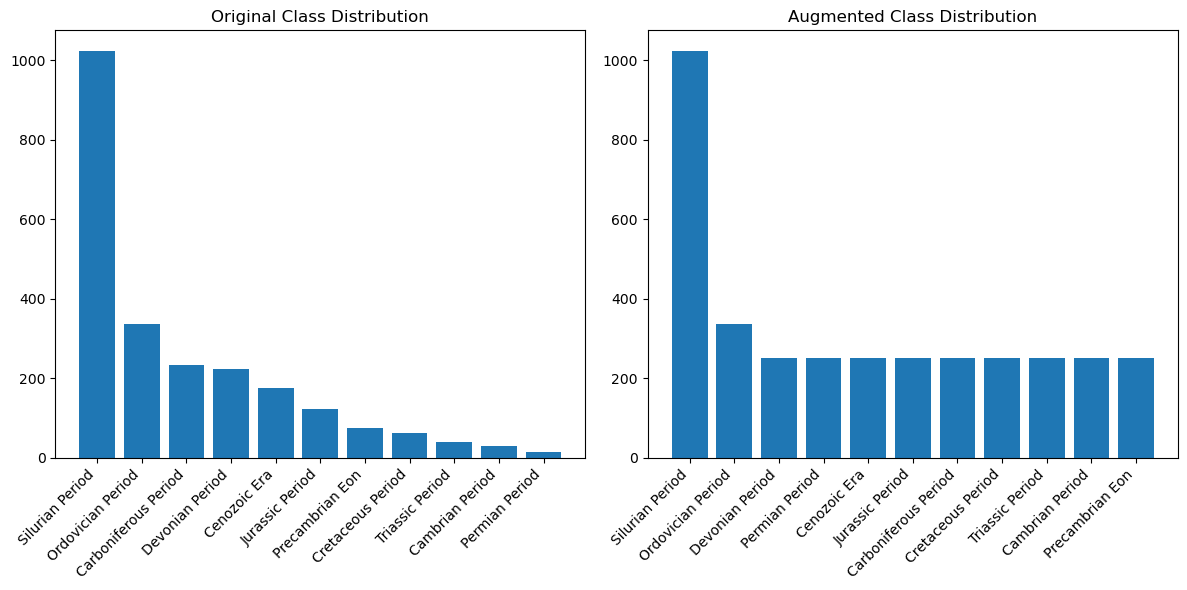

In [46]:
# plot original vs augmented class distribution
augmented_class_counts = df["period"].value_counts()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(class_counts.index, class_counts.values)
plt.title("Original Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.subplot(1, 2, 2)
plt.bar(augmented_class_counts.index, augmented_class_counts.values)
plt.title("Augmented Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()